In [ ]:
# !pip install segmentation_models_pytorch

In [2]:
# IMPORTING NECESSARY LIBRARIES

import numpy as np
import matplotlib.pyplot as plt
import os
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
import segmentation_models_pytorch as smp

In [3]:
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True

In [4]:
# Prevents OpenCV from using multiple threads to avoid RAM leaks with PyTorch

cv2.setNumThreads(0)
cv2.ocl.setUseOpenCL(False)

In [ ]:
# JUST FOR CODE REUSABILITY

import random

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

In [ ]:
# CHECKING THE SHAPE OF INPUT IMAGE AND ITS CORRESPONDING MASK, COLORED MASK

image = cv2.imread("/kaggle/input/datasets/solesensei/solesensei_bdd100k/bdd100k_seg/bdd100k/seg/images/train/0004a4c0-d4dff0ad.jpg")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

mask = cv2.imread("/kaggle/input/datasets/solesensei/solesensei_bdd100k/bdd100k_seg/bdd100k/seg/labels/train/0004a4c0-d4dff0ad_train_id.png", 0)

color_mask = cv2.imread("/kaggle/input/datasets/solesensei/solesensei_bdd100k/bdd100k_seg/bdd100k/seg/color_labels/train/0004a4c0-d4dff0ad_train_color.png")
color_mask = cv2.cvtColor(color_mask, cv2.COLOR_BGR2RGB)

print("IMAGE SHAPE:", image.shape)
print("MASK SHAPE:", mask.shape)
print("COLOR MASK SHAPE:", color_mask.shape)

IMAGE SHAPE: (720, 1280, 3)
MASK SHAPE: (720, 1280)
COLOR MASK SHAPE: (720, 1280, 3)


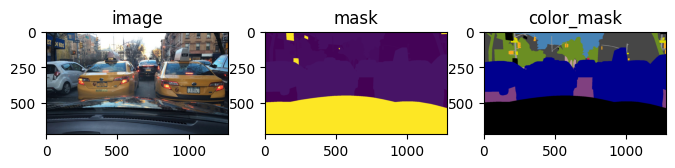

In [7]:
# PLOTTING A SAMPLE IMG,MASK PAIR

plt.figure(figsize=(8,4))

plt.subplot(1,3,1)
plt.imshow(image)
plt.title("image")

plt.subplot(1,3,2)
plt.imshow(mask)
plt.title("mask")

plt.subplot(1,3,3)
plt.imshow(color_mask)
plt.title("color_mask")

plt.show()

In [8]:
print(mask.dtype)
print(np.unique(mask))

uint8
[  0   2   4   5   6   7   8  10  11  13 255]


In [ ]:
# DEFINING PATHS, BATCH SIZE, IMAGE SIZE AND DEVICE

IMG_SIZE = 384
BATCH_SIZE = 24
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

TRAIN_SEG_IMAGES = "/kaggle/input/datasets/solesensei/solesensei_bdd100k/bdd100k_seg/bdd100k/seg/images/train"
TRAIN_SEG_MASKS = "/kaggle/input/datasets/solesensei/solesensei_bdd100k/bdd100k_seg/bdd100k/seg/labels/train"
VAL_SEG_IMAGES = "/kaggle/input/datasets/solesensei/solesensei_bdd100k/bdd100k_seg/bdd100k/seg/images/val"
VAL_SEG_MASKS = "/kaggle/input/datasets/solesensei/solesensei_bdd100k/bdd100k_seg/bdd100k/seg/labels/val"

In [10]:
print("TOTAL TRAINING IMAGES:", len(os.listdir(TRAIN_SEG_IMAGES)))
print("TOTAL TRAINING MASKS:", len(os.listdir(TRAIN_SEG_MASKS)))
print("TOTAL VAL IMAGES:", len(os.listdir(TRAIN_SEG_IMAGES)))
print("TOTAL VAL MASKS:", len(os.listdir(TRAIN_SEG_MASKS)))

TOTAL TRAINING IMAGES: 7000
TOTAL TRAINING MASKS: 7000
TOTAL VAL IMAGES: 7000
TOTAL VAL MASKS: 7000


In [11]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

# DEFINING TRANSFORMATIONS:

train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    
    A.HorizontalFlip(p=0.5),
    
    A.ShiftScaleRotate(shift_limit=0.0625, scale_limit=0.1, rotate_limit=15, p=0.5),
    A.RandomBrightnessContrast(p=0.2),
    
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [12]:
from torch.utils.data import Dataset, DataLoader

class BDDSegmentationDataset(Dataset):

    def __init__(self, image_dir, mask_dir, transform=None):

        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.transform = transform

        self.images = sorted(os.listdir(image_dir))

    def __len__(self):

        return len(self.images)

    def __getitem__(self, idx):

        # IMAGE

        image_name = self.images[idx]

        image_path = os.path.join(
            self.image_dir,
            image_name
        )

        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # MASK

        mask_name = image_name.replace(
            ".jpg",
            "_train_id.png"
        )

        mask_path = os.path.join(
            self.mask_dir,
            mask_name
        )

        mask = cv2.imread(
            mask_path,
            cv2.IMREAD_GRAYSCALE
        )

        # AUGMENTATIONS

        if self.transform is not None:

            augmented = self.transform(
                image=image,
                mask=mask
            )

            image = augmented["image"]
            mask = augmented["mask"]

        mask = mask.long()

        return image, mask

In [ ]:
# DEFINING TRAIN AND VAL DATASETS

train_dataset = BDDSegmentationDataset(
    image_dir=TRAIN_SEG_IMAGES,
    mask_dir=TRAIN_SEG_MASKS,
    transform=train_transform
)

val_dataset = BDDSegmentationDataset(
    image_dir=VAL_SEG_IMAGES,
    mask_dir=VAL_SEG_MASKS,
    transform=val_transform
)

In [14]:
print(len(train_dataset))
print(len(val_dataset))

7000
1000


In [ ]:
# CHECKING SHAPE AND DTYPE OF IMG,MASK PAIR AFTER TRANSFORMATIONS, JUST FOR THE SAKE OF SANITY 

image, mask = train_dataset[0]

print(image.shape)
print(image.dtype)

print(mask.shape)
print(mask.dtype)

print(torch.unique(mask))

torch.Size([3, 384, 384])
torch.float32
torch.Size([384, 384])
torch.int64
tensor([  0,   2,   4,   5,   6,   7,   8,  10,  11,  13, 255])


In [ ]:
# DEFINING TRAIN AND VAL LOADERS

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True, drop_last=True)

val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True, drop_last=False)

In [17]:
images, masks = next(iter(train_loader))

print(images.shape)
print(images.dtype)

print(masks.shape)
print(masks.dtype)

print(torch.unique(masks))

torch.Size([24, 3, 384, 384])
torch.float32
torch.Size([24, 384, 384])
torch.int64
tensor([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,
         14,  15,  17,  18, 255])


In [ ]:
# DEFINING COMBINED LOSS FUNCTION WITH DICE AND CROSS-ENTROPY LOSSES

dice_loss = smp.losses.DiceLoss(
    mode="multiclass",
    from_logits=True,
    ignore_index=255
)

cross_loss = nn.CrossEntropyLoss(ignore_index=255)

def loss_fn(pred, target):
    return ( 0.5 * cross_loss(pred, target) + 0.5 * dice_loss(pred, target) )

In [ ]:
# DEFINING THE IOU METRIC SCORE

def mean_iou(preds, targets, num_classes=19, ignore_index=255):

    preds = torch.argmax(preds, dim=1)

    valid_mask = targets != ignore_index

    preds = preds[valid_mask]
    targets = targets[valid_mask]

    ious = []

    for cls in range(num_classes):

        pred_cls = preds == cls
        target_cls = targets == cls

        intersection = (pred_cls & target_cls).sum().float()
        union = (pred_cls | target_cls).sum().float()

        if union == 0:
            continue

        ious.append(intersection / union)

    if len(ious) == 0:
        return torch.tensor(0.0, device=preds.device)

    return torch.mean(torch.stack(ious))

In [ ]:
# DEFINING A GENERIC TRAINING METHOD FOR TRAINING MODELS!

def train_model(
    model,
    train_loader,
    val_loader,
    epochs,
    model_name
):

    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
    
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='max',
        factor=0.5,
        patience=4
    )
    
    print(f"TRAINING {model_name} ...\n")
    
    best_val_iou = 0.0
    
    for epoch in range(epochs):
    
        # -------- TRAINING --------
        model.train()
        train_loss = 0.0
        train_iou = 0.0
    
        for images, masks in train_loader:
    
            images = images.to(DEVICE)
            masks = masks.to(DEVICE)
    
            # FORWARD PROP
            outputs = model(images.contiguous())
            # CALCULATING LOSS
            loss = loss_fn(outputs, masks)
            # CLEARING PREVIOUS GRADIENTS
            optimizer.zero_grad()
            # CALCULATING NEW GRADIENTS
            loss.backward()
            # UPDATING PARAMETERS
            optimizer.step()
    
            train_loss += loss.item()
            train_iou += mean_iou(outputs.detach(), masks).item()
    
        train_loss /= len(train_loader)
        train_iou /= len(train_loader)
    
        # -------- VALIDATION --------
        model.eval()
        val_loss = 0.0
        val_iou = 0.0
    
        with torch.no_grad():
    
            for images, masks in val_loader:
    
                images = images.to(DEVICE)
                masks = masks.to(DEVICE)
    
                # FORWARD PROP
                outputs = model(images)
                # CALCULATING LOSS
                loss = loss_fn(outputs, masks)
    
                val_loss += loss.item()
                val_iou += mean_iou(outputs, masks).item()
    
        val_loss /= len(val_loader)
        val_iou /= len(val_loader)
        
        scheduler.step(val_iou)
    
        current_lr = optimizer.param_groups[0]['lr']
        
        print(
            f"Epoch [{epoch+1}/{epochs}] | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Train IoU: {train_iou:.4f} | "
            f"Val IoU: {val_iou:.4f} | "
            f"LR: {current_lr:.6f}"
        )
    
        # SAVING BEST MODEL BASED ON VALIDATION IOU
        if val_iou > best_val_iou:
    
            print(
                f"Validation IoU improved "
                f"({best_val_iou:.4f} → {val_iou:.4f}).\nSaving the model..."
            )
    
            torch.save({
                'epoch': epoch + 1,
                'model_state': model.state_dict(),
                'optimizer_state': optimizer.state_dict(),
                'scheduler_state': scheduler.state_dict(),
                'train_loss': train_loss,
                'val_loss': val_loss,
                'train_iou': train_iou,
                'val_iou': val_iou,
                'best_val_iou': best_val_iou
            }, f"{model_name}.pth")
    
            best_val_iou = val_iou

In [ ]:
# U-NET++ MODEL

model = smp.UnetPlusPlus(
    encoder_name="efficientnet-b3",
    encoder_weights="imagenet",
    in_channels=3,
    classes=19,
    activation=None
)

model = model.to(DEVICE)

if torch.cuda.device_count() > 1:
    model = nn.DataParallel(model)

In [ ]:
train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=100,
    model_name="unetpp_effb3_01"
)

In [ ]:
# Defining BDD100K Color Palette

PALETTE = np.array([
    [128, 64,128],   # 0 Road
    [244, 35,232],   # 1 Sidewalk
    [ 70, 70, 70],   # 2 Building
    [102,102,156],   # 3 Wall
    [190,153,153],   # 4 Fence
    [153,153,153],   # 5 Pole
    [250,170, 30],   # 6 Traffic Light
    [220,220,  0],   # 7 Traffic Sign
    [107,142, 35],   # 8 Vegetation
    [152,251,152],   # 9 Terrain
    [ 70,130,180],   # 10 Sky
    [220, 20, 60],   # 11 Person
    [255,  0,  0],   # 12 Rider
    [  0,  0,142],   # 13 Car
    [  0,  0, 70],   # 14 Truck
    [  0, 60,100],   # 15 Bus
    [  0, 80,100],   # 16 Train
    [  0,  0,230],   # 17 Motorcycle
    [119, 11, 32]    # 18 Bicycle
], dtype=np.uint8)

In [ ]:
# DEFINING A FUNCTION TO CONVERT MASKS TO RGB

def decode_mask(mask):

    color_mask = np.zeros((*mask.shape,3), dtype=np.uint8)

    for class_id in range(19):
        color_mask[mask == class_id] = PALETTE[class_id]

    return color_mask

In [ ]:
# DEFINING A FUNTION TO DISPLAY THE PREDICTIONS

def display_preds(
    model,
    test_loader,
    model_name="U-Net++",
    max_images=10,
    min_iou=0.50
):

    model.eval()

    MEAN = np.array([0.485,0.456,0.406])
    STD  = np.array([0.229,0.224,0.225])

    shown = 0

    with torch.no_grad():

        for images, masks in test_loader:

            images = images.to(DEVICE)
            masks = masks.to(DEVICE)

            logits = model(images)

            preds = torch.argmax(logits, dim=1)

            for b in range(images.size(0)):

                if shown >= max_images:
                    return

                miou = mean_iou(
                    logits[b].unsqueeze(0),
                    masks[b].unsqueeze(0)
                ).item()

                if miou < min_iou:
                    continue

                img = images[b].cpu().permute(1,2,0).numpy()
                img = img * STD + MEAN
                img = np.clip(img,0,1)

                gt = masks[b].cpu().numpy()
                pred = preds[b].cpu().numpy()

                gt_color = decode_mask(gt)
                pred_color = decode_mask(pred)

                plt.figure(figsize=(18,6))

                plt.subplot(1,3,1)
                plt.imshow(img)
                plt.title("Input Image")
                plt.axis("off")

                plt.subplot(1,3,2)
                plt.imshow(gt_color)
                plt.title("Ground Truth")
                plt.axis("off")

                plt.subplot(1,3,3)
                plt.imshow(pred_color)
                plt.title(f"{model_name}\nmIoU: {miou:.3f}")
                plt.axis("off")

                plt.tight_layout()
                plt.show()

                shown += 1

In [ ]:
display_preds(
    model=model,
    test_loader=val_loader,
    model_name="U-Net++ EfficientNet-B3",
    max_images=10,
    min_iou=0.70
)

**THANK U**